Чтение данных и чистка

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

    # Все данные нужных типов
df = pd.read_csv("bike_trips.csv")
df["station"] = df["station"].str.lower().str.strip()
df["duration_min"] = pd.to_numeric(df["duration_min"].str.strip().str.replace(" мин", "", regex=True))
df["start_time"] = pd.to_datetime(df["start_time"])

weather = pd.read_csv("weather.csv")
weather["date"] = pd.to_datetime(weather["date"])

    # Отбор некорректных строк (ушло 1188)
df.drop_duplicates(inplace=True)    # 358 дубликатов удалено
df = df[df["duration_min"] > 0]     # 830 строк удалено в связи с некорректным значением duration_min
df.rename(columns={"start_time": "date"}, inplace=True)

Общий датасет с погодой по дням

In [16]:
daily = (
    df.set_index("date")
        .groupby("station")
        .resample("D")
        .agg(trips = ("trip_id", "count"))
        .reset_index()
)

daily = daily.merge(weather, on="date", how="left").sort_values(["station", "is_holiday", "precipitation_mm", "temperature_c"], ascending=[True, True, True, False], ignore_index=True)
daily["temp_bin"] = pd.qcut(daily["temperature_c"], q=3, labels=["холодно", "умеренно", "тепло"])
daily["rain_bin"] = np.where(daily["precipitation_mm"] > 0, "дождь", "сухо")

Настройки к графикам

In [17]:
no_holidays = daily[daily["is_holiday"] == False].groupby(["station", "rain_bin", "temp_bin"])["trips"].mean().reset_index()
holidays = daily[daily["is_holiday"] == True].groupby(["station", "rain_bin", "temp_bin"])["trips"].mean().reset_index()

weather_palette = {
    "сухо и холодно":   "#5E4B30",   # тёмно-синий
    "сухо и умеренно":  "#EEF10E",   # зелёный
    "сухо и тепло":     "#12E224",   # красный
    "дождь и холодно":  "#371C8F",   # фиолетовый
    "дождь и умеренно": "#2E58A7",   # жёлто-коричневый
    "дождь и тепло":    "#00C8FA",   # голубой
}

weather_order_not_holidays = ["сухо и холодно", "сухо и умеренно", "сухо и тепло",
                 "дождь и холодно", "дождь и умеренно", "дождь и тепло"]
weather_order_holidays = ["сухо и холодно", "сухо и умеренно", "сухо и тепло",
                 "дождь и холодно", "дождь и умеренно"]

График 1: будние дни

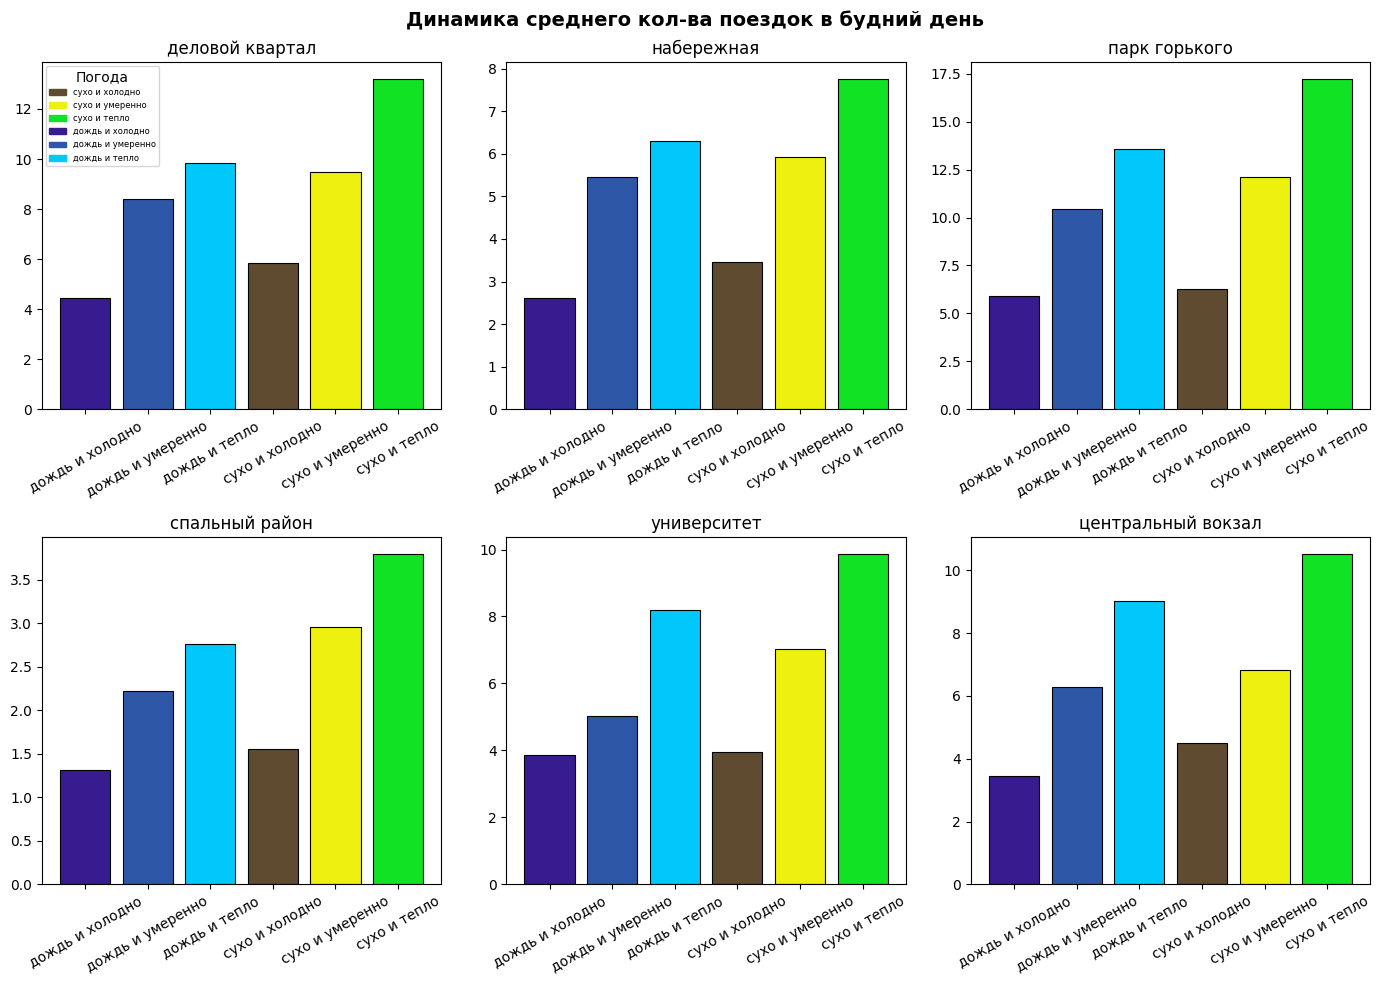

In [18]:
fig1, ax1 = plt.subplots(2, 3, figsize=(14, 10))
axes = ax1.flatten()

for i, (station, group) in enumerate(no_holidays.groupby("station")):
    ax1 = axes[i]
    group["weather"] = group["rain_bin"] + " и " + group["temp_bin"].astype(str)
    colors = [weather_palette[w] for w in group["weather"]]
    ax1.bar(group["weather"], group["trips"], color=colors, edgecolor="black", linewidth=0.8)
    ax1.set_title(station)
    ax1.tick_params(axis='x', rotation=30)

handles = [plt.Rectangle((0,0),1,1, color=weather_palette[key]) for key in weather_order_not_holidays]
axes[0].legend(handles, weather_order_not_holidays, fontsize=6, loc='upper left', title="Погода")
fig1.suptitle("Динамика среднего кол-ва поездок в будний день", fontsize=14, fontweight="bold")
fig1.tight_layout()

Из графиков можно сделать вывод, что среднее кол-во поездок в будни зависит колько от одного фактора погоды - температуры, в то время как наличие\отсутствие осадков почти никак не влияет

График 2: выходные

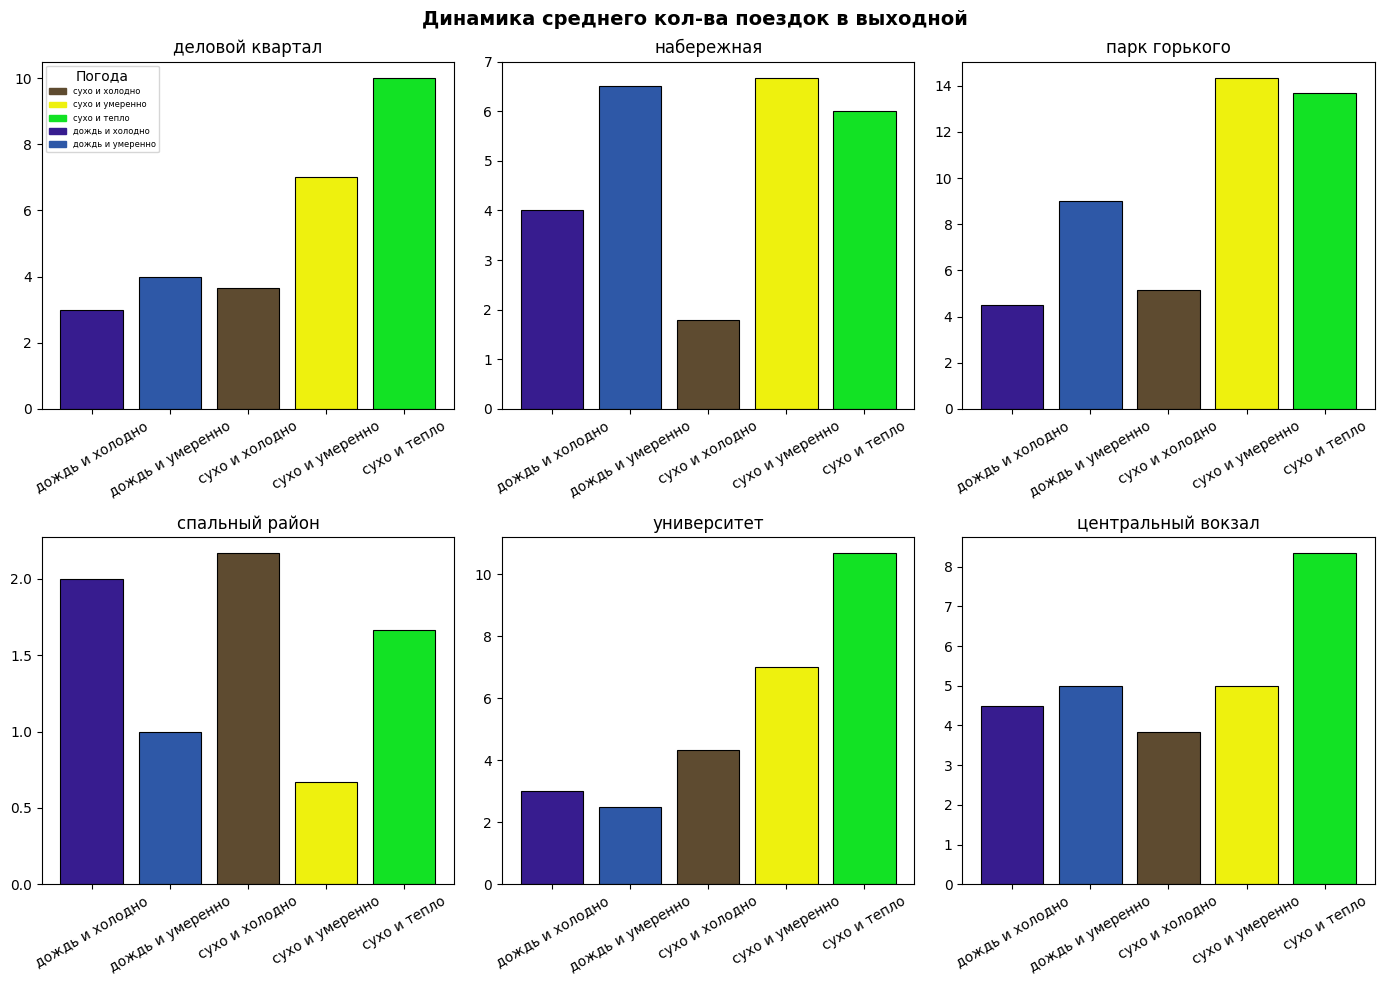

In [19]:
fig2, ax2 = plt.subplots(2, 3, figsize=(14, 10))
axes = ax2.flatten()

for i, (station, group) in enumerate(holidays.groupby("station")):
    ax2 = axes[i]
    group["weather"] = group["rain_bin"] + " и " + group["temp_bin"].astype(str)
    colors = [weather_palette[w] for w in group["weather"]]
    ax2.bar(group["weather"], group["trips"], color=colors, edgecolor="black", linewidth=0.8)
    ax2.set_title(station)
    ax2.tick_params(axis="x", rotation=30)

handles = [plt.Rectangle((0,0),1,1, color=weather_palette[key]) for key in weather_order_holidays]
axes[0].legend(handles, weather_order_holidays, fontsize=6, loc='upper left', title="Погода")
fig2.suptitle("Динамика среднего кол-ва поездок в выходной", fontsize=14, fontweight="bold")
fig2.tight_layout()

В выходные дни значения у разных станций сильно разнятся, но можно сделать вывод, что сухая и тёплая погода предпочтительна везде, в то время как в дождь и холод охотно ездят только в спальном районе и на набережной